#  Skincare Ingredient Conflict Predictor
## Notebook 1 : Exploratory Data Analysis (EDA)

#### **Project**: Ingredient Conflict Detection  
#### **Dataset:** `ingredient_conflict_datase.csv`  
---

#### Problem Definition

In skincare, combining incompatible ingredients can cause **skin irritation, reduced efficacy, or even chemical reactions**. 
For example, mixing Retinol with AHA acids is known to cause over-exfoliation and skin barrier damage.

**Our objective:** To solve this problem we decided to build a model that predicts whether two given skincare ingredients will **conflict** it enables our skincare app to warn users before they layer incompatible products.

**ML objective:** Binary classification  
- `risk = 1` => Conflict (avoid combining)  
- `risk = 0` => Safe (can be used together)

---
## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
# Color palette for the project
SAFE_COLOR   = '#4CAF50'   
RISK_COLOR   = '#E53935'   
ACCENT_COLOR = '#7E57C2'  
#create folder for figures
os.makedirs('./figures', exist_ok=True)

print('Libraries loaded successfully ')

Libraries loaded successfully 


---
## 2. Load the Dataset

In [3]:
df = pd.read_csv('./data/ingredient_conflict_dataset.csv')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 4,371 rows × 33 columns


,ingredient_a,ingredient_b,risk,pH_a,category_a,is_acid_a,is_oxidizer_a,photosensitizing_a,exfoliant_a,barrier_repair_a,...,exfoliant_b,barrier_repair_b,anti_inflammatory_b,brightening_b,humectant_b,retinoid_b,antioxidant_b,comedogenic_b,irritation_level_b,strength_level_b
0,Retinol,Tretinoin,1,5.5,retinoid,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0
1,Retinol,Retinaldehyde,1,5.5,retinoid,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0
2,Retinol,Bakuchiol,0,5.5,retinoid,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,Retinol,Adapalene,1,5.5,retinoid,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0
4,Retinol,Retinyl Palmitate,1,5.5,retinoid,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [4]:
# Column overview
print('Columns and dtypes:')
print(df.dtypes.to_string())

Columns and dtypes:
ingredient_a            object
ingredient_b            object
risk                     int64
pH_a                   float64
category_a              object
is_acid_a              float64
is_oxidizer_a          float64
photosensitizing_a     float64
exfoliant_a            float64
barrier_repair_a       float64
anti_inflammatory_a    float64
brightening_a          float64
humectant_a            float64
retinoid_a             float64
antioxidant_a          float64
comedogenic_a          float64
irritation_level_a     float64
strength_level_a       float64
pH_b                   float64
category_b              object
is_acid_b              float64
is_oxidizer_b          float64
photosensitizing_b     float64
exfoliant_b            float64
barrier_repair_b       float64
anti_inflammatory_b    float64
brightening_b          float64
humectant_b            float64
retinoid_b             float64
antioxidant_b          float64
comedogenic_b          float64
irritation_level_b 

**Column structure:**  
Each row represents a **pair** of skincare ingredients (A and B). For each ingredient, we have:
- `pH` : acidity level
- `category` : functional category (AHA, retinoid, humectant, etc.)
- 10 binary property flags: `is_acid`, `is_oxidizer`, `photosensitizing`, `exfoliant`, `barrier_repair`, `anti_inflammatory`, `brightening`, `humectant`, `retinoid`, `antioxidant`, `comedogenic`
- `irritation_level` : 0 (low) -> 2 (high)
- `strength_level` : 0 (mild) _> 2 (strong)
- `risk` : **our target**: 1 = conflict, 0 = safe

---
## 3. Descriptive Statistics

In [5]:
df.describe()

,risk,pH_a,is_acid_a,is_oxidizer_a,photosensitizing_a,exfoliant_a,barrier_repair_a,anti_inflammatory_a,brightening_a,humectant_a,...,exfoliant_b,barrier_repair_b,anti_inflammatory_b,brightening_b,humectant_b,retinoid_b,antioxidant_b,comedogenic_b,irritation_level_b,strength_level_b
count,4371.000000,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000,...,3152.000000,3152.000000,3152.000000,3152.000000,3152.000000,3152.000000,3152.000000,3152.000000,3152.000000,3152.000000
mean,0.113933,5.151582,0.325737,0.019035,0.344504,0.268901,0.313405,0.443164,0.519303,0.156032,...,0.065355,0.661802,0.596764,0.211612,0.198921,0.221129,0.188135,0.101840,0.131662,0.418147
std,0.317766,1.146300,0.468712,0.136666,0.475270,0.443448,0.463940,0.496826,0.499694,0.362934,...,0.247191,0.473171,0.490625,0.408516,0.399252,0.415073,0.390882,0.302486,0.448687,0.586228
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,6.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000


In [6]:
# How many unique ingredients are in the dataset?
all_ingredients = pd.concat([df['ingredient_a'], df['ingredient_b']]).unique()
print(f'Unique ingredients: {len(all_ingredients)}')
print(f'Total ingredient pairs: {len(df):,}')

# Are pairs symmetric? (i.e. does (A,B) also appear as (B,A)?)
pairs_ab = set(zip(df['ingredient_a'], df['ingredient_b']))
pairs_ba = set(zip(df['ingredient_b'], df['ingredient_a']))
symmetric = len(pairs_ab & pairs_ba)
print(f'Symmetric (A,B)/(B,A) pairs: {symmetric}')

Unique ingredients: 94
Total ingredient pairs: 4,371
Symmetric (A,B)/(B,A) pairs: 0


---
## 4. Target Variable :Class Distribution

Risk distribution:
              Count  Percentage (%)
Safe (0)       3873           88.61
Conflict (1)    498           11.39


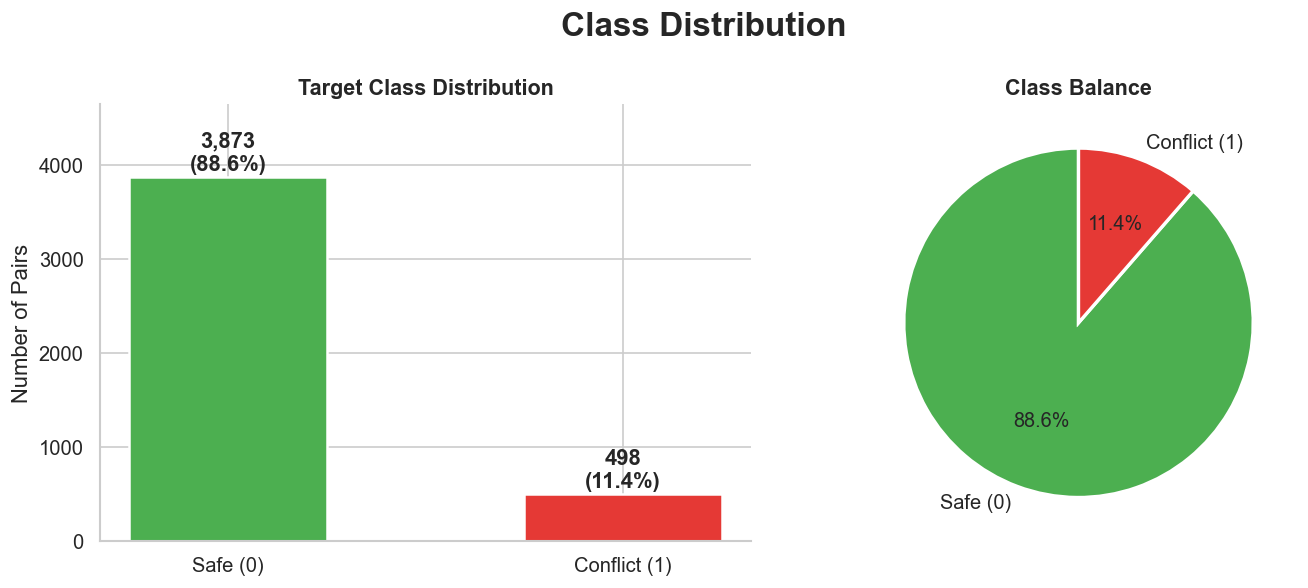

In [7]:
target_counts = df['risk'].value_counts()
target_pct = df['risk'].value_counts(normalize=True) * 100
print('Risk distribution:')
summary = pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)})
summary.index = ['Safe (0)', 'Conflict (1)']
print(summary.to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
bars = axes[0].bar(['Safe (0)', 'Conflict (1)'], target_counts.values,color=[SAFE_COLOR, RISK_COLOR], edgecolor='white', linewidth=1.5, width=0.5)
for bar, count, pct_val in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count:,}\n({pct_val:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Pairs')
axes[0].set_ylim(0, target_counts.max() * 1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
axes[1].pie(target_counts.values, labels=['Safe (0)', 'Conflict (1)'],
            colors=[SAFE_COLOR, RISK_COLOR], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution ', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./figures/01_target_distribution.png', bbox_inches='tight')
plt.show()

---
## 5. Missing Values Analysis

In [8]:
# Missing value counts and percentages
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(f'Total columns with missing values: {len(missing_df)}')
print()
print(missing_df.to_string())


Total columns with missing values: 30

                     Missing Count  Missing %
anti_inflammatory_b           1219      27.89
is_oxidizer_b                 1219      27.89
strength_level_b              1219      27.89
comedogenic_b                 1219      27.89
irritation_level_b            1219      27.89
retinoid_b                    1219      27.89
humectant_b                   1219      27.89
brightening_b                 1219      27.89
antioxidant_b                 1219      27.89
category_b                    1219      27.89
barrier_repair_b              1219      27.89
photosensitizing_b            1219      27.89
exfoliant_b                   1219      27.89
pH_b                          1219      27.89
is_acid_b                     1219      27.89
barrier_repair_a               641      14.66
category_a                     641      14.66
is_acid_a                      641      14.66
anti_inflammatory_a            641      14.66
irritation_level_a             641      1

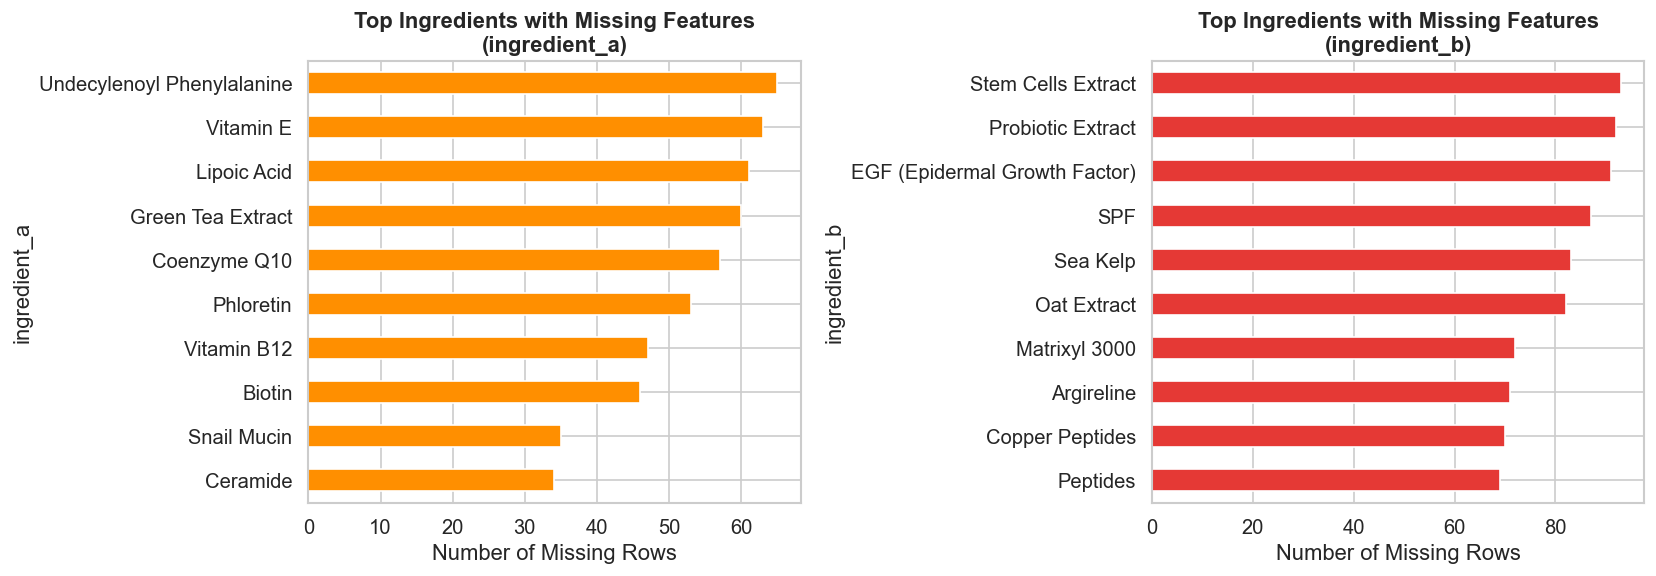

In [9]:
# Which ingredients cause the most missing values?
missing_ing_a = df[df['pH_a'].isna()]['ingredient_a'].value_counts().head(10)
missing_ing_b = df[df['pH_b'].isna()]['ingredient_b'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_ing_a.sort_values().plot(kind='barh', ax=axes[0], color='#FF8F00', edgecolor='white')
axes[0].set_title('Top Ingredients with Missing Features\n(ingredient_a)', fontweight='bold')
axes[0].set_xlabel('Number of Missing Rows')

missing_ing_b.sort_values().plot(kind='barh', ax=axes[1], color=RISK_COLOR, edgecolor='white')
axes[1].set_title('Top Ingredients with Missing Features\n(ingredient_b)', fontweight='bold')
axes[1].set_xlabel('Number of Missing Rows')

plt.tight_layout()
plt.savefig('./figures/02_missing_by_ingredient.png', bbox_inches='tight')
plt.show()

---
## 6. Feature Distributions

### 6.1 pH Distribution

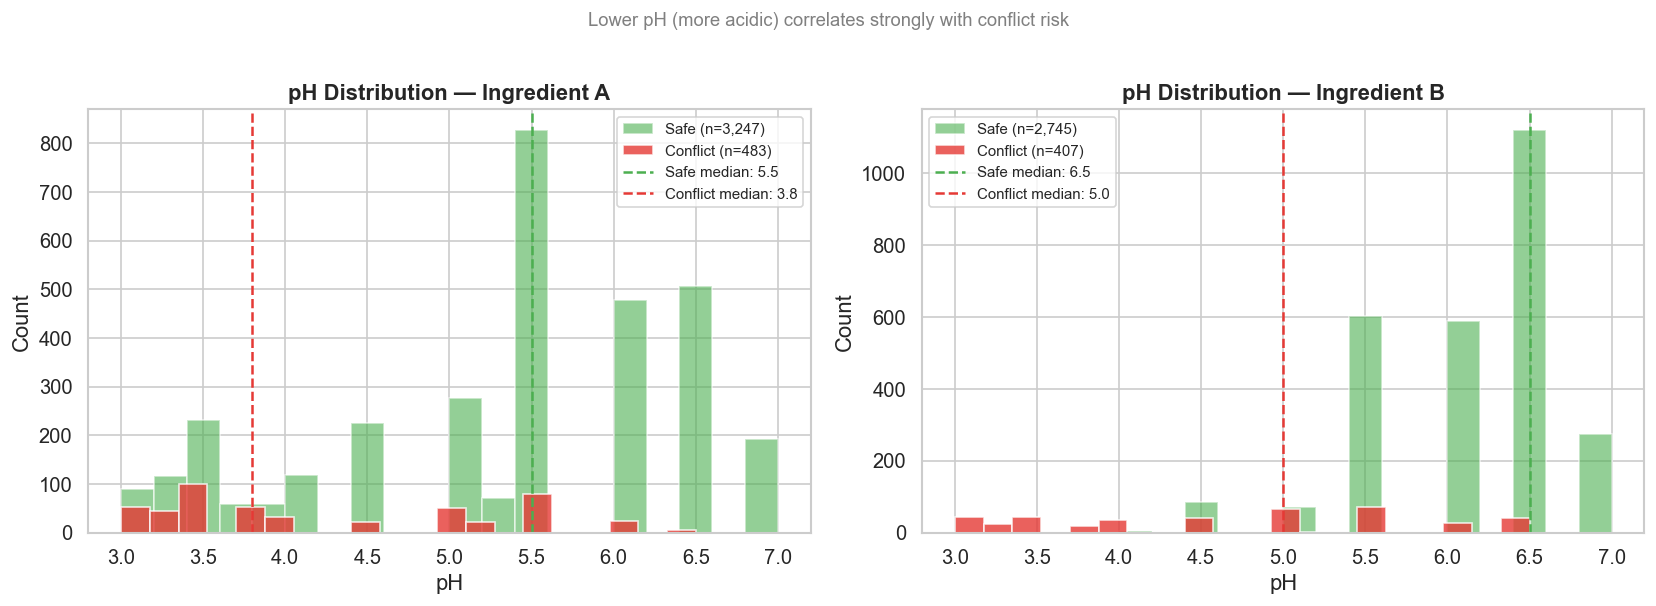

Mean pH for ingredient_a: 5.15
Mean pH for ingredient_b: 5.93


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes, ['pH_a', 'pH_b'], ['Ingredient A', 'Ingredient B']):
    safe_vals    = df[df['risk'] == 0][col].dropna()
    conflict_vals = df[df['risk'] == 1][col].dropna()
    ax.hist(safe_vals, bins=20, alpha=0.6, color=SAFE_COLOR,
            label=f'Safe (n={len(safe_vals):,})', edgecolor='white')
    ax.hist(conflict_vals, bins=20, alpha=0.8, color=RISK_COLOR,
            label=f'Conflict (n={len(conflict_vals):,})', edgecolor='white')
    ax.axvline(safe_vals.median(), color=SAFE_COLOR, linestyle='--', linewidth=1.5,
               label=f'Safe median: {safe_vals.median():.1f}')
    ax.axvline(conflict_vals.median(), color=RISK_COLOR, linestyle='--', linewidth=1.5,
               label=f'Conflict median: {conflict_vals.median():.1f}')
    ax.set_xlabel('pH')
    ax.set_ylabel('Count')
    ax.set_title(f'pH Distribution — {label}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Lower pH (more acidic) correlates strongly with conflict risk',
             fontsize=11, color='gray', y=1.01)
plt.tight_layout()
plt.savefig('./figures/03_pH_distribution.png', bbox_inches='tight')
plt.show()
#caluclate the mean pH for a and b 
mean_ph_a = df['pH_a'].mean()
mean_ph_b = df['pH_b'].mean()
print(f'Mean pH for ingredient_a: {mean_ph_a:.2f}')
print(f'Mean pH for ingredient_b: {mean_ph_b:.2f}')

### 6.2 Category Distribution

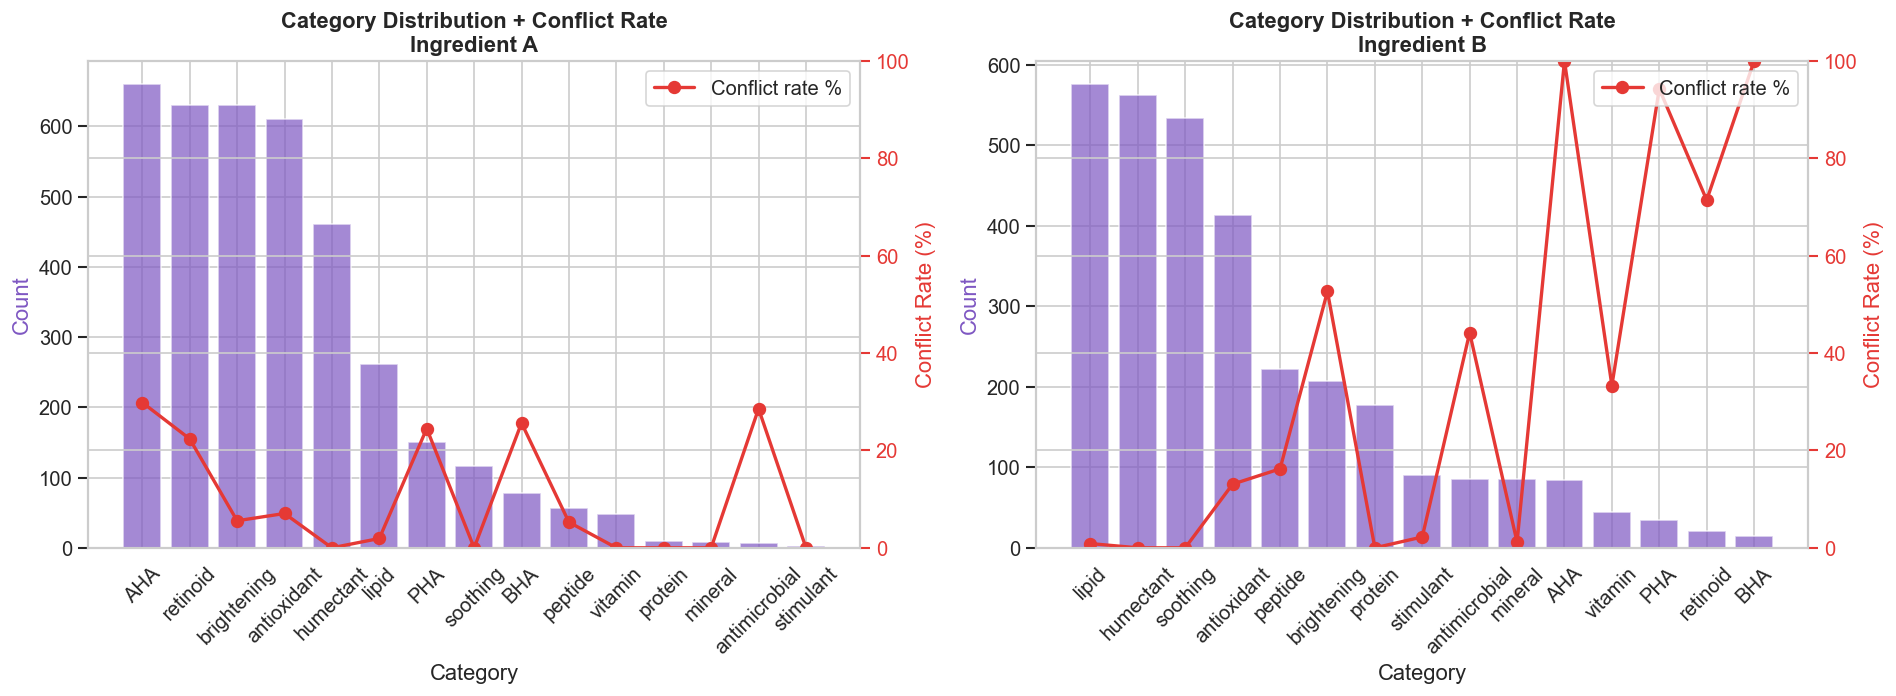

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, label in zip(axes, ['category_a', 'category_b'], ['Ingredient A', 'Ingredient B']):
    cat_counts = df[col].value_counts()
    conflict_rate = df.groupby(col)['risk'].mean().reindex(cat_counts.index)
    
    bars = ax.bar(cat_counts.index, cat_counts.values,
                  color=ACCENT_COLOR, alpha=0.7, edgecolor='white')
    ax2 = ax.twinx()
    ax2.plot(cat_counts.index, conflict_rate.values * 100,
             'o-', color=RISK_COLOR, linewidth=2, markersize=7, label='Conflict rate %')
    ax2.set_ylabel('Conflict Rate (%)', color=RISK_COLOR)
    ax2.tick_params(axis='y', colors=RISK_COLOR)
    ax2.set_ylim(0, 100)
    
    ax.set_title(f'Category Distribution + Conflict Rate\n{label}', fontweight='bold')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count', color=ACCENT_COLOR)
    ax.tick_params(axis='x', rotation=45)
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('./figures/04_category_distribution.png', bbox_inches='tight')
plt.show()

### 6.3 Irritation & Strength Levels

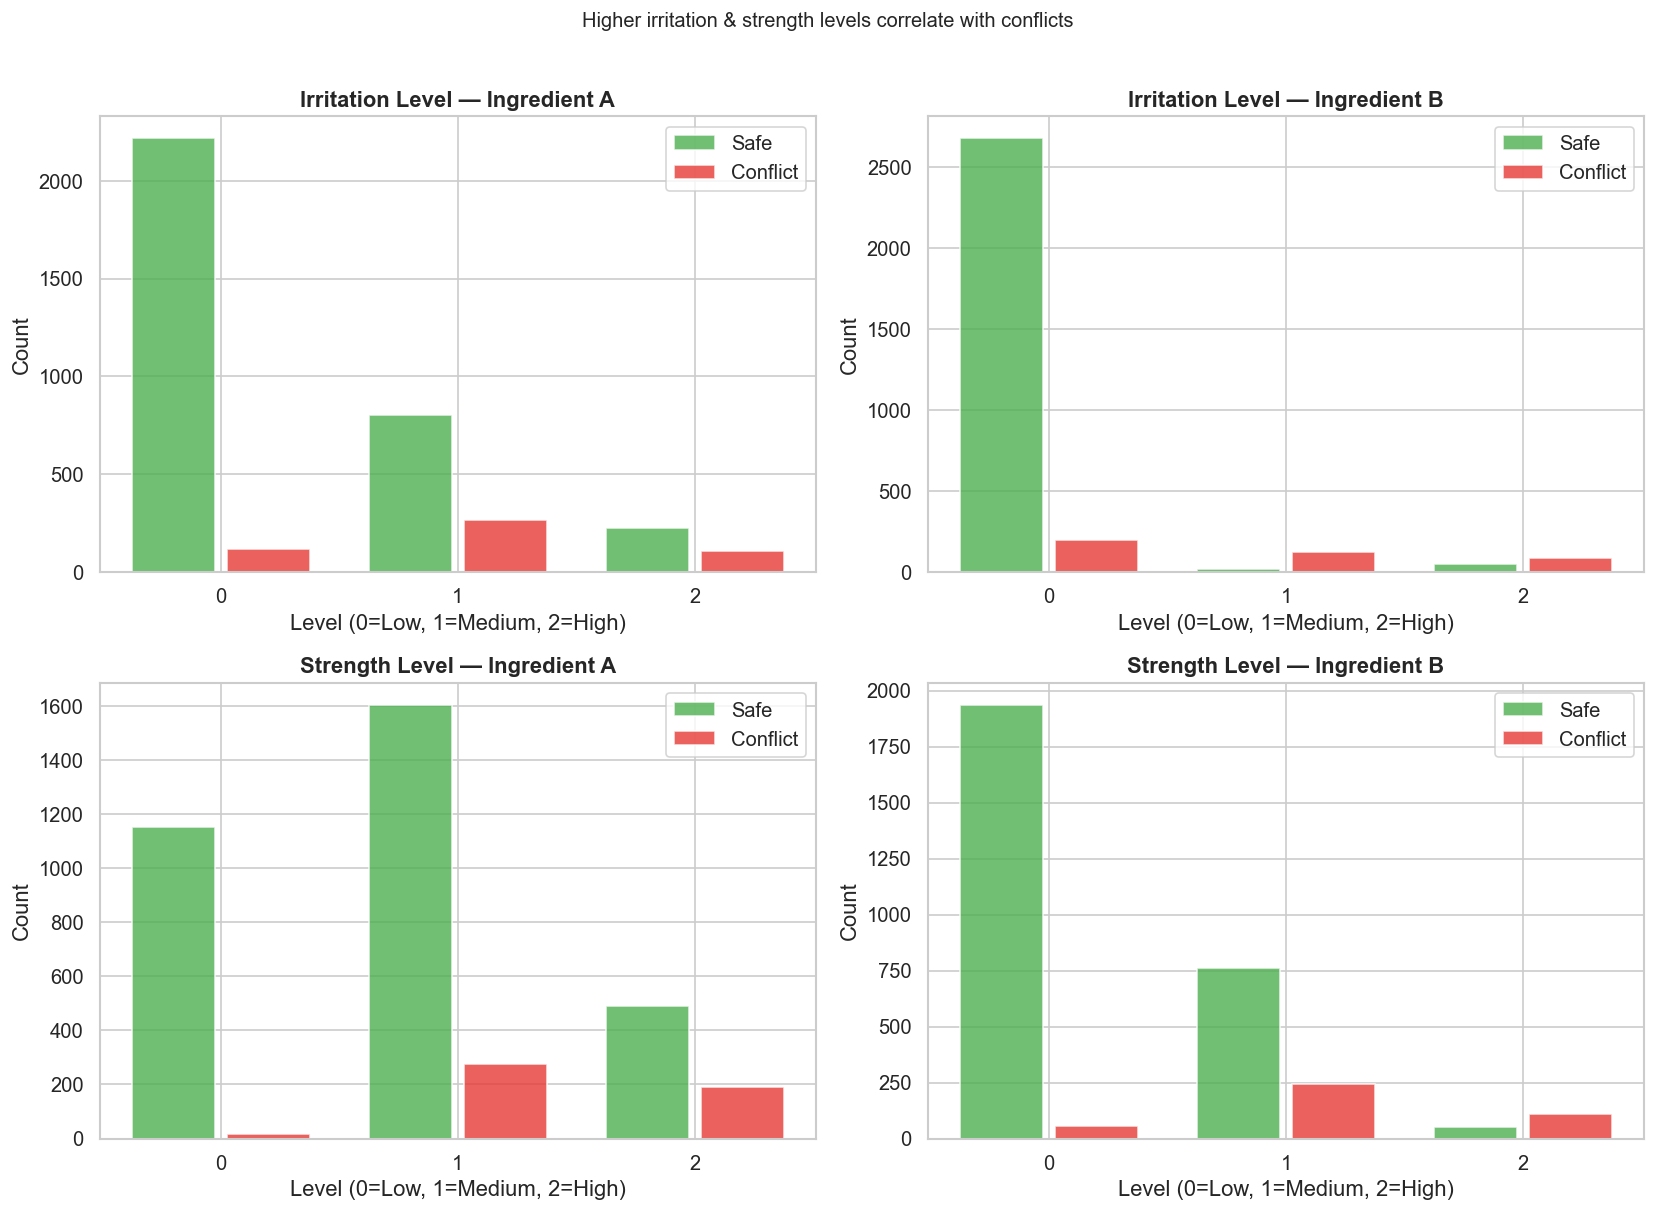

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

level_cols = ['irritation_level_a', 'irritation_level_b', 'strength_level_a', 'strength_level_b']
titles = ['Irritation Level — Ingredient A', 'Irritation Level — Ingredient B',
          'Strength Level — Ingredient A', 'Strength Level — Ingredient B']

for ax, col, title in zip(axes.flat, level_cols, titles):
    for risk_val, color, label in [(0, SAFE_COLOR, 'Safe'), (1, RISK_COLOR, 'Conflict')]:
        data = df[df['risk'] == risk_val][col].dropna()
        counts = data.value_counts().sort_index()
        ax.bar(counts.index + (0.2 if risk_val else -0.2), counts.values,
               width=0.35, color=color, alpha=0.8, label=label, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Level (0=Low, 1=Medium, 2=High)')
    ax.set_ylabel('Count')
    ax.set_xticks([0, 1, 2])
    ax.legend()

plt.suptitle('Higher irritation & strength levels correlate with conflicts', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('./figures/05_levels_distribution.png', bbox_inches='tight')
plt.show()

### 6.4 Binary Property Flags

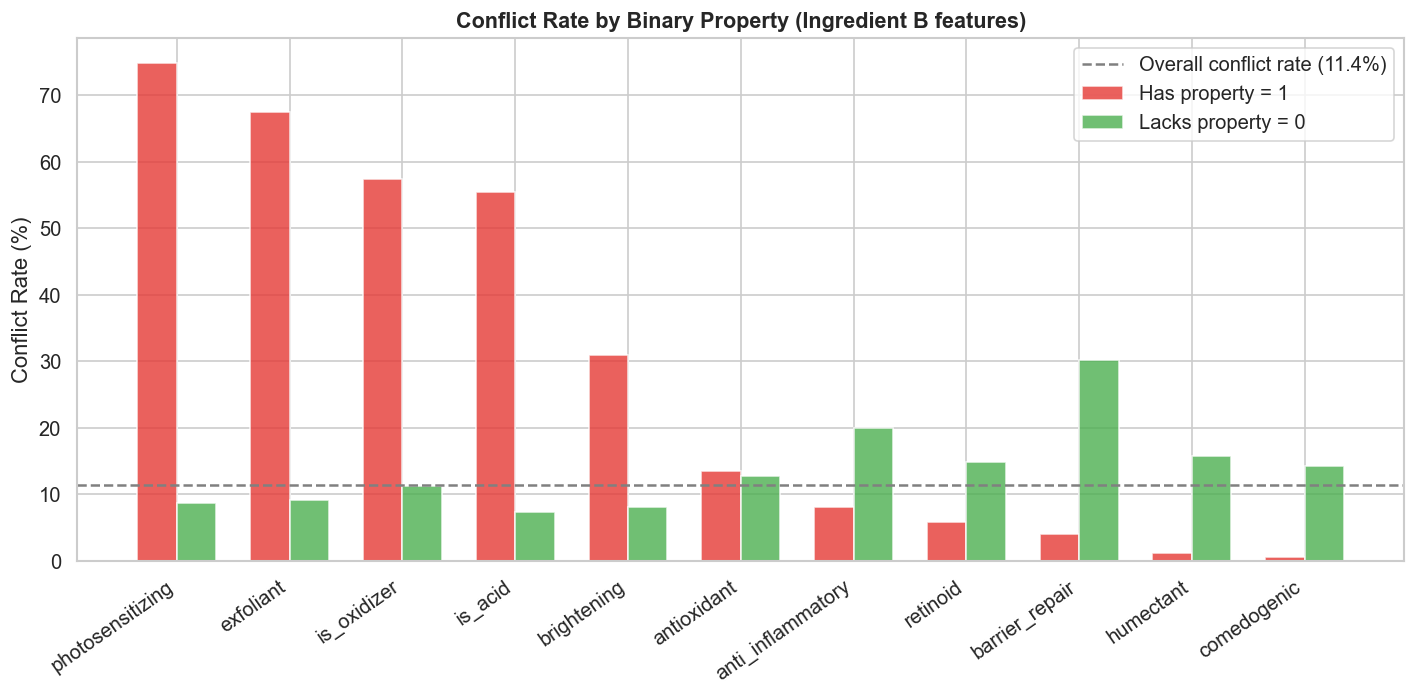

In [13]:
binary_props = ['is_acid', 'is_oxidizer', 'photosensitizing', 'exfoliant',
                'barrier_repair', 'anti_inflammatory', 'brightening',
                'humectant', 'retinoid', 'antioxidant', 'comedogenic']

# Compute conflict rate when property = 1 vs 0, for _b features (higher correlation)
conflict_rates_b = {}
for prop in binary_props:
    col = f'{prop}_b'
    if col in df.columns:
        rate_1 = df[df[col] == 1]['risk'].mean()
        rate_0 = df[df[col] == 0]['risk'].mean()
        conflict_rates_b[prop] = {'Has property': rate_1 * 100, 'Lacks property': rate_0 * 100}

rates_df = pd.DataFrame(conflict_rates_b).T.sort_values('Has property', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(rates_df))
width = 0.35
ax.bar(x - width/2, rates_df['Has property'], width, color=RISK_COLOR,
       alpha=0.8, label='Has property = 1', edgecolor='white')
ax.bar(x + width/2, rates_df['Lacks property'], width, color=SAFE_COLOR,
       alpha=0.8, label='Lacks property = 0', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(rates_df.index, rotation=35, ha='right')
ax.set_ylabel('Conflict Rate (%)')
ax.set_title('Conflict Rate by Binary Property (Ingredient B features)',
             fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(y=df['risk'].mean()*100, color='gray', linestyle='--',
           linewidth=1.5, label=f'Overall conflict rate ({df["risk"].mean()*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('./figures/06_binary_flags_conflict_rate.png', bbox_inches='tight')
plt.show()


---
## 7. Correlation Analysis

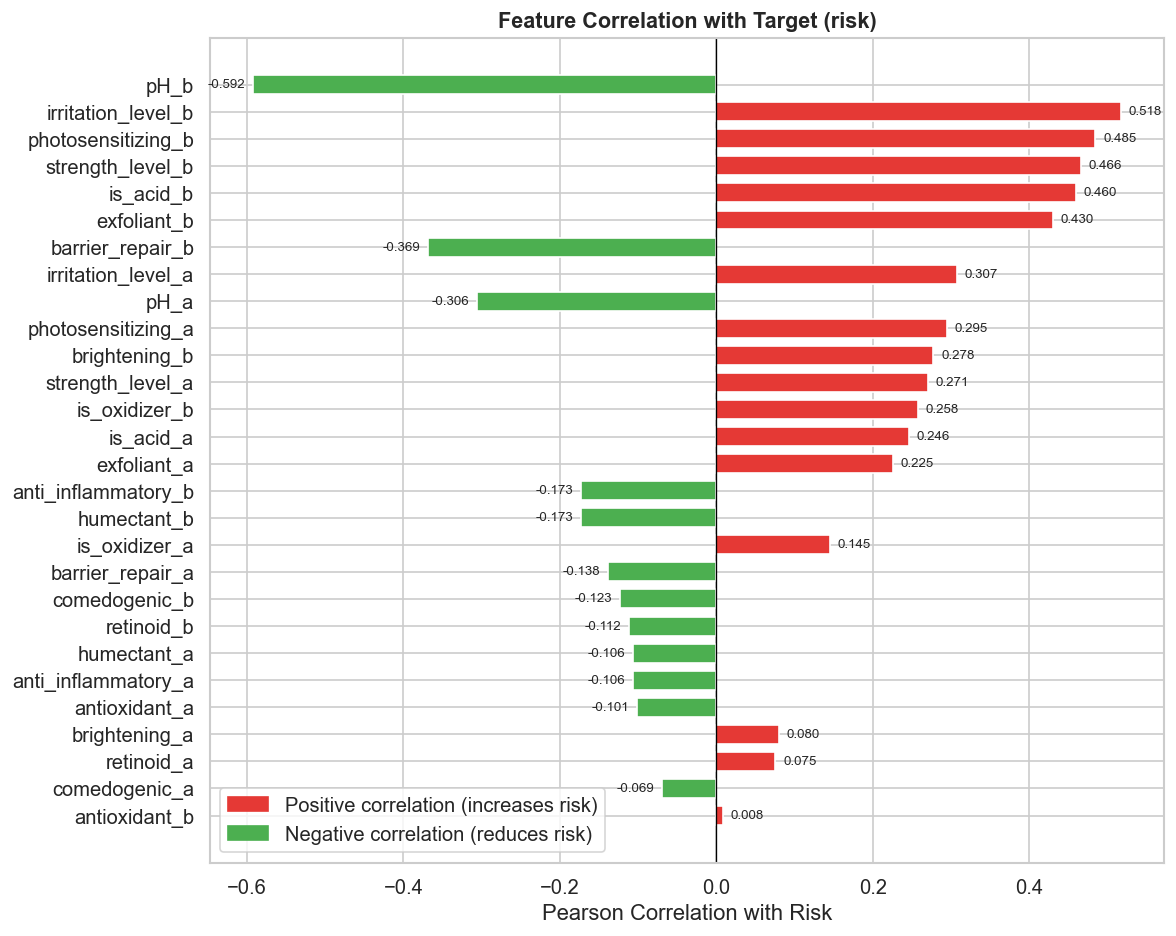

Top 5 features positively correlated with conflict:
irritation_level_b    0.517553
photosensitizing_b    0.484809
strength_level_b      0.466179
is_acid_b             0.459926
exfoliant_b           0.430265

Top 5 features negatively correlated with conflict:
pH_b                  -0.591956
barrier_repair_b      -0.368666
pH_a                  -0.306348
anti_inflammatory_b   -0.173352
humectant_b           -0.172920


In [14]:
# Correlation of all numeric features with target
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_with_risk = df[numeric_cols].corr()['risk'].drop('risk').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [RISK_COLOR if v > 0 else SAFE_COLOR for v in corr_with_risk.values]
bars = ax.barh(corr_with_risk.index[::-1], corr_with_risk.values[::-1],
               color=colors[::-1], edgecolor='white', height=0.7)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Risk')
ax.set_title('Feature Correlation with Target (risk)', fontweight='bold', fontsize=13)

# Add value labels
for bar, val in zip(bars, corr_with_risk.values[::-1]):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

red_patch = mpatches.Patch(color=RISK_COLOR, label='Positive correlation (increases risk)')
green_patch = mpatches.Patch(color=SAFE_COLOR, label='Negative correlation (reduces risk)')
ax.legend(handles=[red_patch, green_patch])
plt.tight_layout()
plt.savefig('./figures/07_feature_correlation.png', bbox_inches='tight')
plt.show()

print('Top 5 features positively correlated with conflict:')
print(corr_with_risk[corr_with_risk > 0].head(5).to_string())
print()
print('Top 5 features negatively correlated with conflict:')
print(corr_with_risk[corr_with_risk < 0].head(5).to_string())

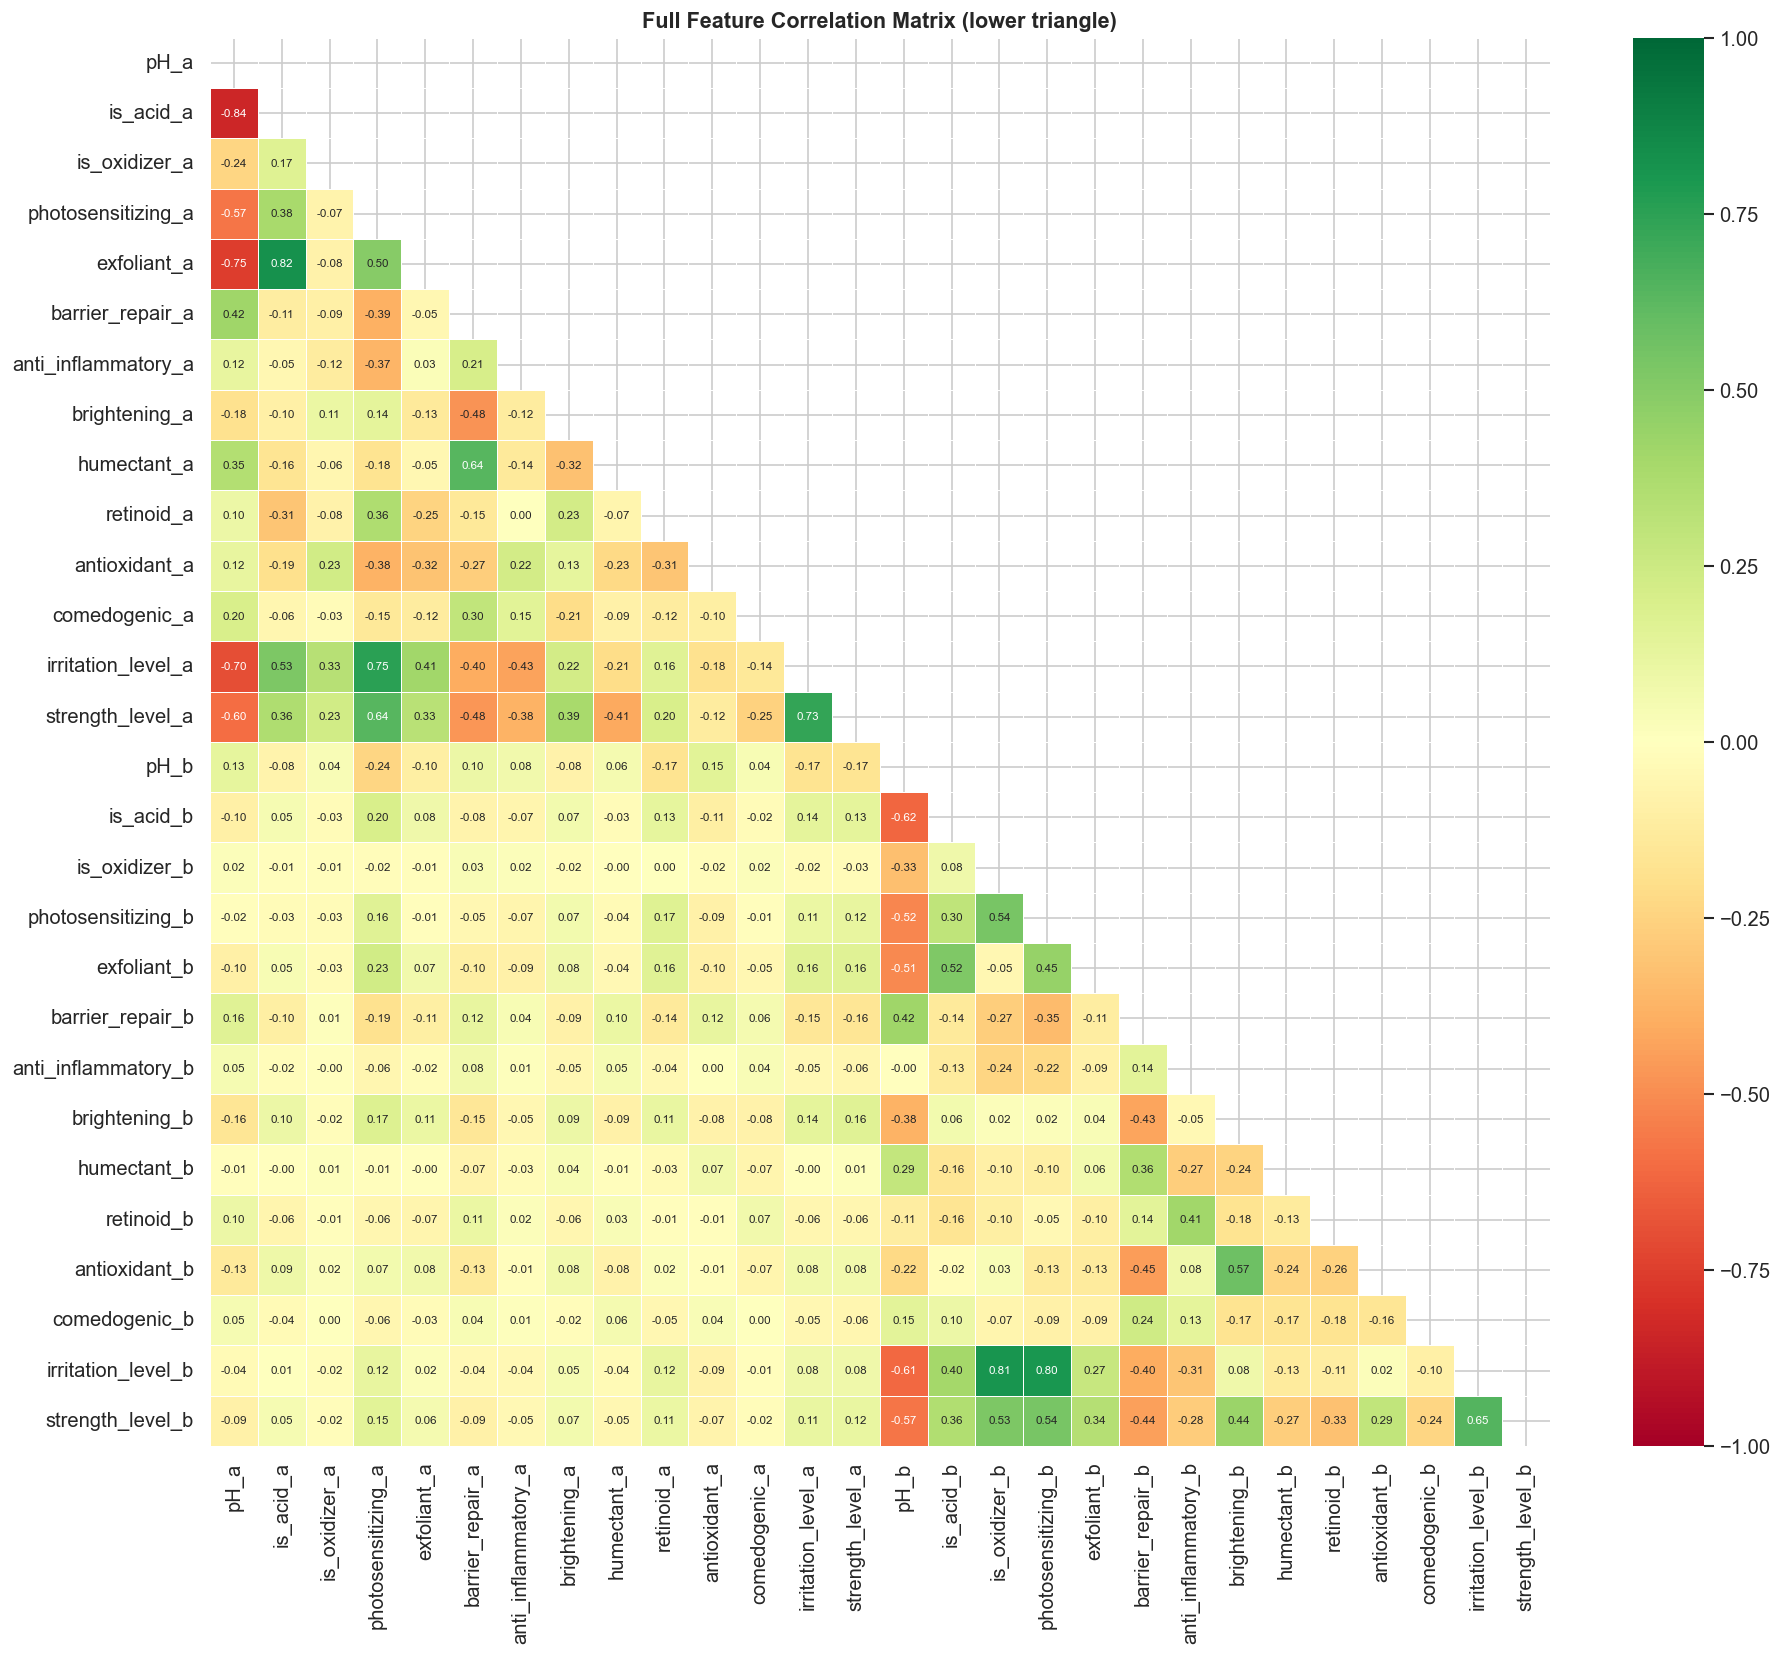

In [15]:
# Full correlation heatmap between numeric features
num_df = df[numeric_cols].drop(columns=['risk'])
corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Full Feature Correlation Matrix (lower triangle)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./figures/08_correlation_matrix.png', bbox_inches='tight')
plt.show()

---
## 8. Conflict Patterns Analysis

### 8.1 Top Conflicting Ingredients

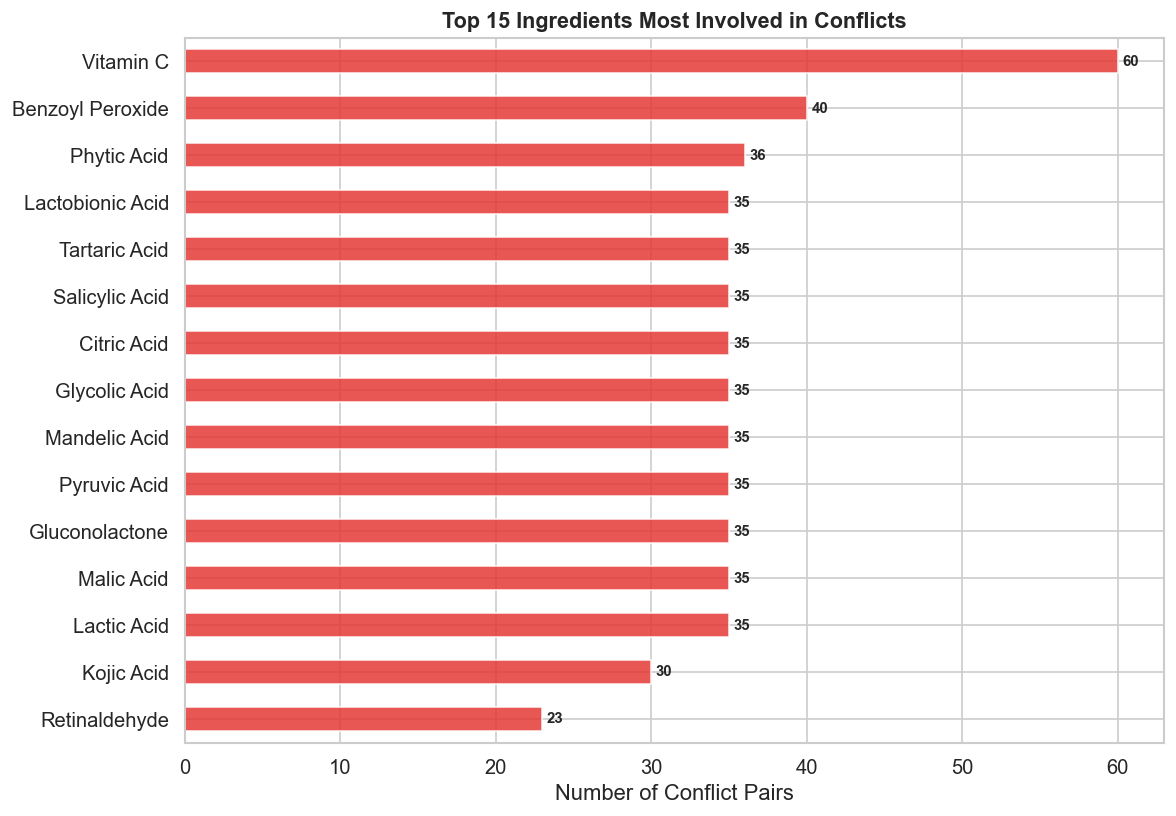

In [16]:
conflict_df = df[df['risk'] == 1]
# Combine both sides
all_conflict_ings = pd.concat([conflict_df['ingredient_a'],conflict_df['ingredient_b']]).value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
all_conflict_ings.sort_values().plot(kind='barh', color=RISK_COLOR, ax=ax,
                                     alpha=0.85, edgecolor='white')
ax.set_title('Top 15 Ingredients Most Involved in Conflicts', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Conflict Pairs')
for i, v in enumerate(all_conflict_ings.sort_values().values):
    ax.text(v + 0.3, i, str(v), va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('./figures/10_top_conflicting_ingredients.png', bbox_inches='tight')
plt.show()

### 8.2 Category-to-Category Conflict Heatmap

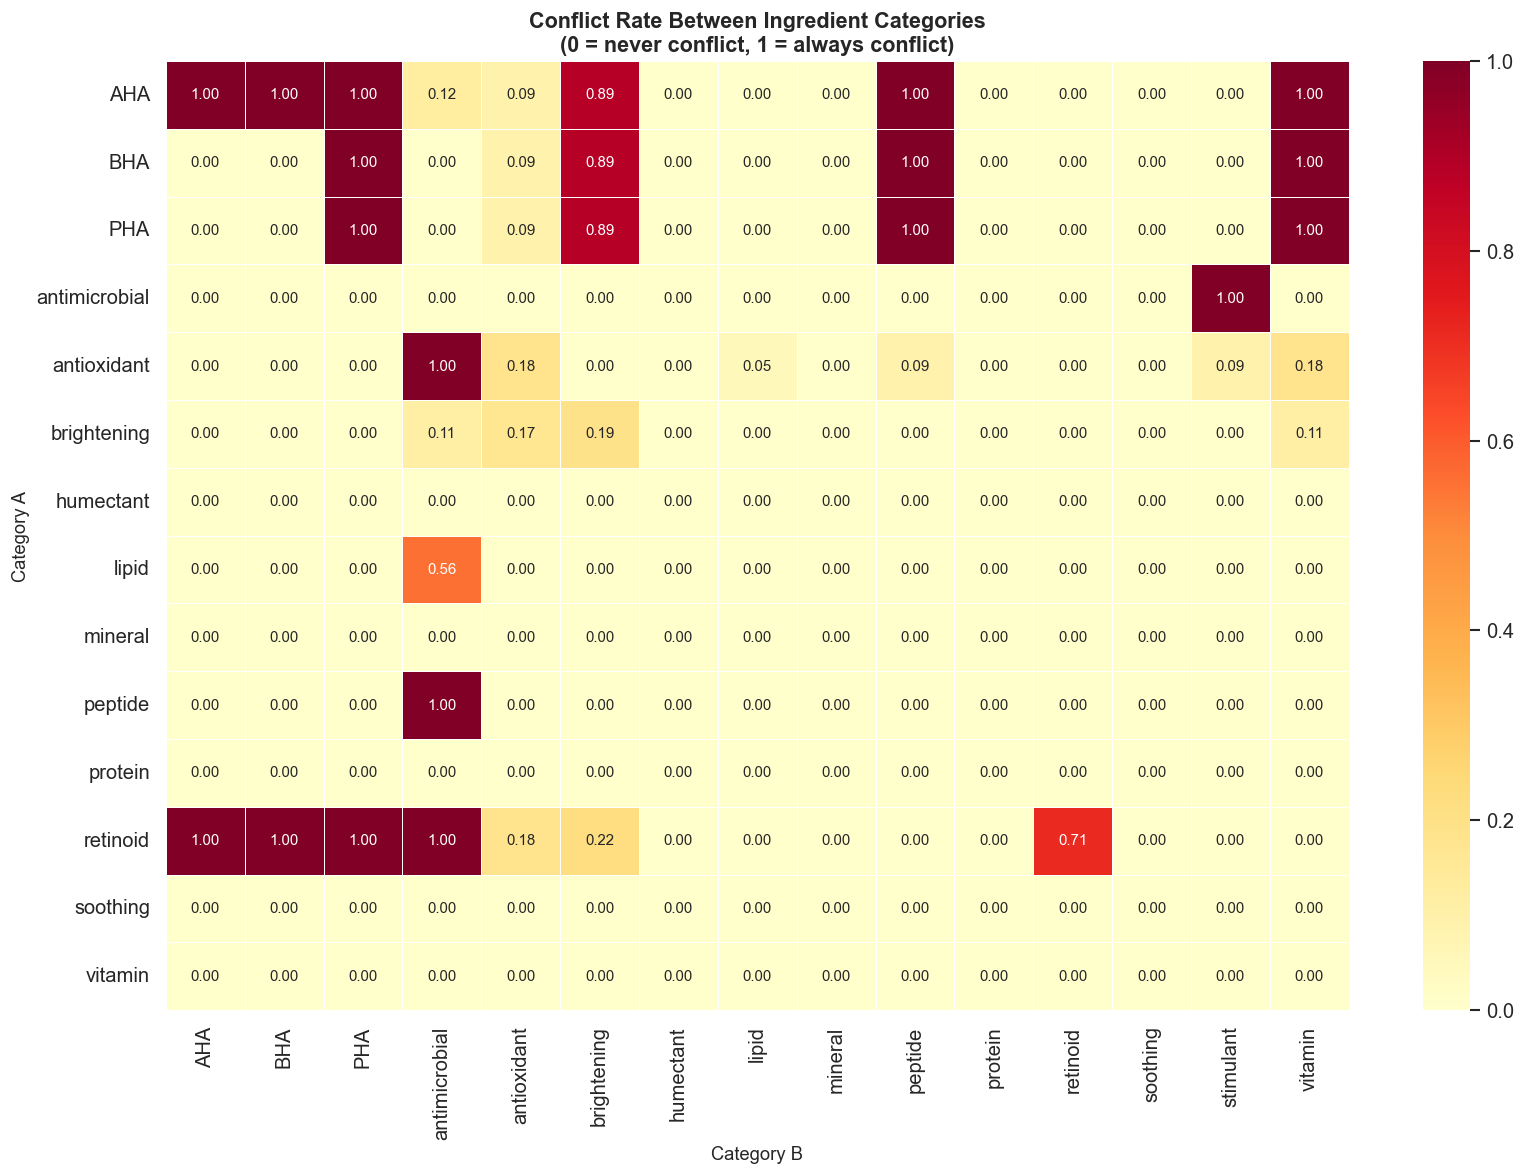

Top conflicting category pairs (min 5 samples):
 category_a    category_b  conflict_rate  total_conflicts
        AHA           AHA            1.0               28
        AHA           BHA            1.0                8
        AHA           PHA            1.0               16
        AHA       vitamin            1.0                8
        AHA       peptide            1.0               24
        PHA       peptide            1.0                6
antioxidant antimicrobial            1.0               11
   retinoid antimicrobial            1.0                7
   retinoid           PHA            1.0               14
   retinoid           BHA            1.0                7


In [17]:
# Build a conflict rate matrix between categories
cat_pairs = df.dropna(subset=['category_a', 'category_b'])
conflict_matrix = cat_pairs.groupby(['category_a', 'category_b'])['risk'].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(conflict_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Conflict Rate Between Ingredient Categories\n(0 = never conflict, 1 = always conflict)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Category B', fontsize=11)
ax.set_ylabel('Category A', fontsize=11)
plt.tight_layout()
plt.savefig('./figures/11_category_conflict_heatmap.png', bbox_inches='tight')
plt.show()

# Top conflicting category pairs
top_pairs = cat_pairs.groupby(['category_a', 'category_b'])['risk'].agg(['mean', 'sum']).reset_index()
top_pairs.columns = ['category_a', 'category_b', 'conflict_rate', 'total_conflicts']
top_pairs = top_pairs[top_pairs['total_conflicts'] >= 5].sort_values('conflict_rate', ascending=False)
print('Top conflicting category pairs (min 5 samples):')
print(top_pairs.head(10).to_string(index=False))

---
## 9. Outlier Analysis

In [18]:
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | bounds [{lower:.2f}, {upper:.2f}]")

risk: 498 outliers | bounds [0.00, 0.00]
pH_a: 0 outliers | bounds [1.00, 9.00]
is_acid_a: 0 outliers | bounds [-1.50, 2.50]
is_oxidizer_a: 71 outliers | bounds [0.00, 0.00]
photosensitizing_a: 0 outliers | bounds [-1.50, 2.50]
exfoliant_a: 0 outliers | bounds [-1.50, 2.50]
barrier_repair_a: 0 outliers | bounds [-1.50, 2.50]
anti_inflammatory_a: 0 outliers | bounds [-1.50, 2.50]
brightening_a: 0 outliers | bounds [-1.50, 2.50]
humectant_a: 582 outliers | bounds [0.00, 0.00]
retinoid_a: 0 outliers | bounds [-1.50, 2.50]
antioxidant_a: 802 outliers | bounds [0.00, 0.00]
comedogenic_a: 144 outliers | bounds [0.00, 0.00]
irritation_level_a: 0 outliers | bounds [-1.50, 2.50]
strength_level_a: 0 outliers | bounds [-1.50, 2.50]
pH_b: 128 outliers | bounds [4.00, 8.00]
is_acid_b: 366 outliers | bounds [0.00, 0.00]
is_oxidizer_b: 115 outliers | bounds [0.00, 0.00]
photosensitizing_b: 203 outliers | bounds [0.00, 0.00]
exfoliant_b: 206 outliers | bounds [0.00, 0.00]
barrier_repair_b: 0 outliers 

---
## 10. Feature Engineering Preview

Based on EDA insights, we can engineer new features for the modeling notebook:

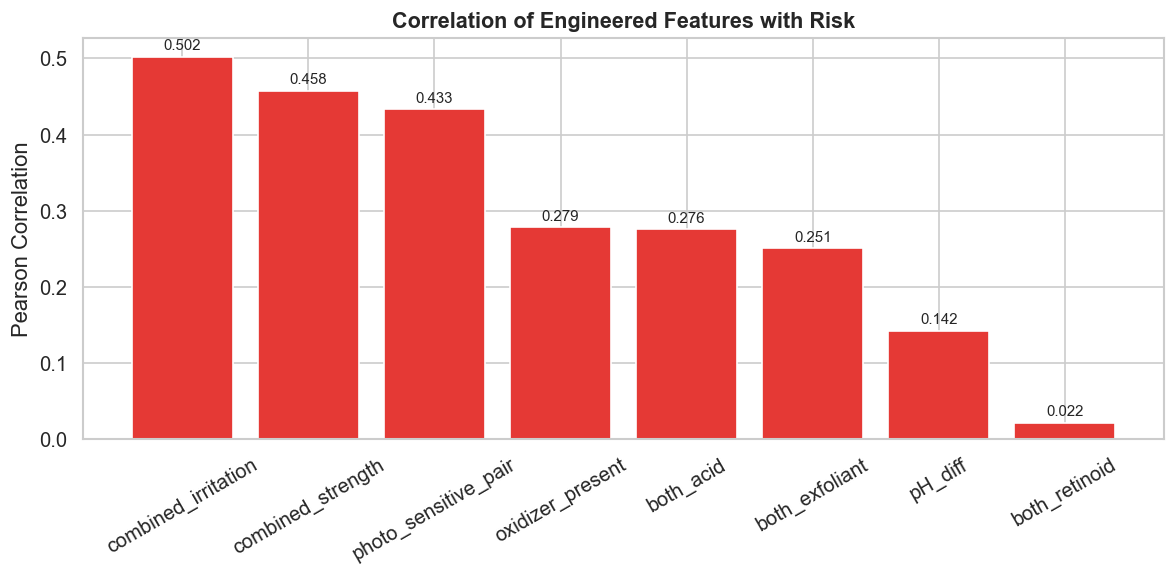

In [19]:
# Preview engineered features and their correlation with risk
eng = df.copy()
# pH difference
eng['pH_diff'] = abs(eng['pH_a'] - eng['pH_b'])
# Combined irritation and strength scores
eng['combined_irritation'] = eng['irritation_level_a'].fillna(0) + eng['irritation_level_b'].fillna(0)
eng['combined_strength']   = eng['strength_level_a'].fillna(0) + eng['strength_level_b'].fillna(0)
# Interaction flags
eng['both_retinoid']    = (eng['retinoid_a'].fillna(0) * eng['retinoid_b'].fillna(0))
eng['both_exfoliant']   = (eng['exfoliant_a'].fillna(0) * eng['exfoliant_b'].fillna(0))
eng['both_acid']        = (eng['is_acid_a'].fillna(0) * eng['is_acid_b'].fillna(0))
eng['oxidizer_present'] = ((eng['is_oxidizer_a'].fillna(0) + eng['is_oxidizer_b'].fillna(0)) > 0).astype(int)
eng['photo_sensitive_pair'] = (eng['photosensitizing_a'].fillna(0) * eng['photosensitizing_b'].fillna(0))

new_features = ['pH_diff', 'combined_irritation', 'combined_strength',
                'both_retinoid', 'both_exfoliant', 'both_acid',
                'oxidizer_present', 'photo_sensitive_pair']

eng_corr = eng[new_features + ['risk']].corr()['risk'].drop('risk').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [RISK_COLOR if v > 0 else SAFE_COLOR for v in eng_corr.values]
ax.bar(eng_corr.index, eng_corr.values, color=colors, edgecolor='white')
ax.set_title('Correlation of Engineered Features with Risk', fontweight='bold', fontsize=13)
ax.set_ylabel('Pearson Correlation')
ax.tick_params(axis='x', rotation=30)
ax.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(eng_corr.values):
    ax.text(i, v + (0.005 if v >= 0 else -0.01), f'{v:.3f}',
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
plt.tight_layout()
plt.savefig('./figures/14_engineered_features.png', bbox_inches='tight')
plt.show()

